In [46]:
import kagglehub
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [48]:

data_transforms = {
    "train": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomCrop(48, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    "test": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
}

# Paths to dataset
train_dir = path + "/fer2013plus/fer2013/train"
test_dir = path + "/fer2013plus/fer2013/test"

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms["train"])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms["test"])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

print("Train loader and test loader created!")

# Check a sample batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels)

# Get class-to-label mapping
class_names = train_dataset.classes
print("Class Names:", class_names)

# Example: label 0 corresponds to the first class
print("Label 0 is:", class_names[0])



Train loader and test loader created!
Image batch shape: torch.Size([16, 1, 48, 48])
Labels batch shape: torch.Size([16])
Labels: tensor([5, 7, 5, 4, 6, 6, 0, 6, 7, 5, 5, 6, 5, 3, 0, 6])
Class Names: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Label 0 is: anger


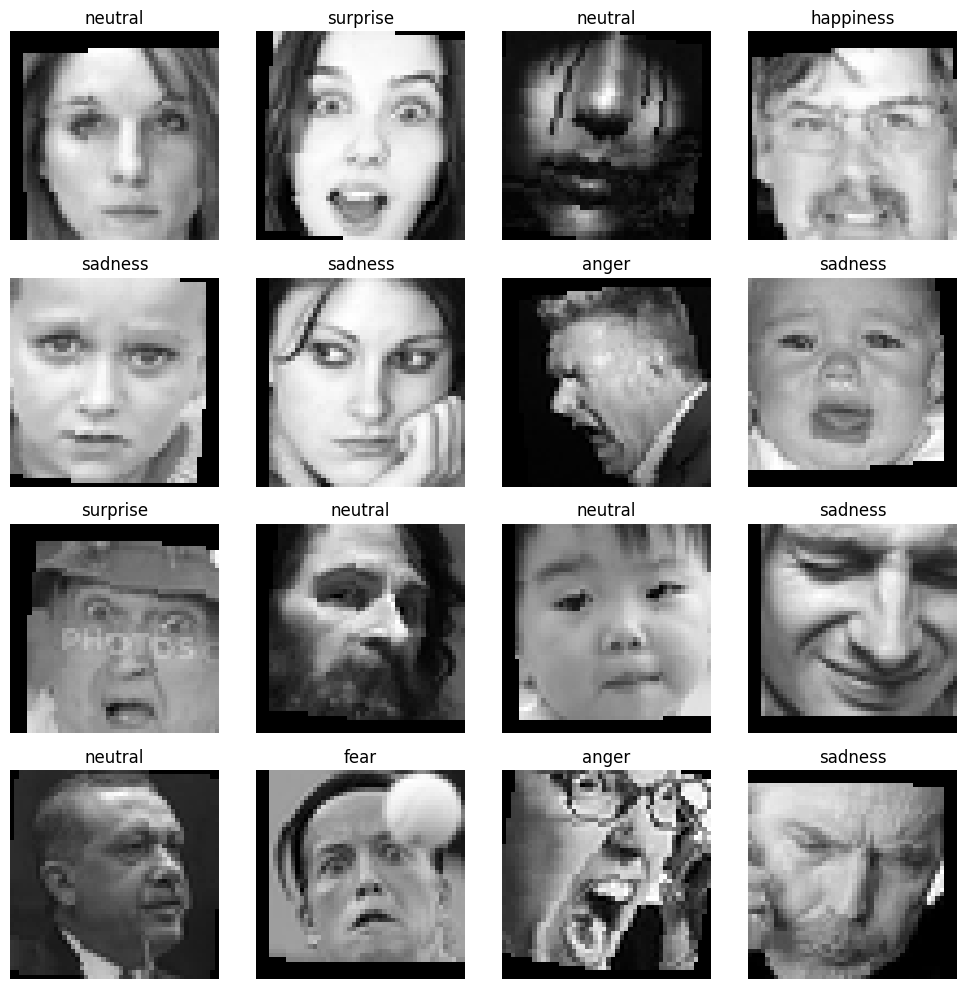

In [49]:
def plot_image_batch(images, labels, class_names):
    """
    Plots a batch of images with their corresponding labels.

    Args:
        images (Tensor): A batch of images (shape: [batch_size, channels, height, width]).
        labels (Tensor): Corresponding labels for the images.
        class_names (list): List of class names corresponding to the labels.
    """

    images = images.permute(0, 2, 3, 1).numpy()

    images = images * 0.5 + 0.5

    batch_size = images.shape[0]
    grid_size = int(batch_size ** 0.5)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        if i < batch_size:

            ax.imshow(images[i].squeeze(), cmap="gray" if images[i].shape[-1] == 1 else None)

            ax.set_title(class_names[labels[i]])
            ax.axis("off")
        else:

            ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_image_batch(images, labels, class_names)


In [50]:

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(in_features=128 * 6 * 6, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=8)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 6 * 6)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


cnn_model = CNN()

In [52]:
# Step 4: Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)  # call optimizer

In [53]:
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, print_every=100, patience=5):
    """
    Trains a given model with early stopping and specified parameters.

    Args:
        model: The model to train.
        train_loader: DataLoader for the training dataset.
        val_loader: DataLoader for the validation dataset.
        optimizer: Optimizer for training (e.g., Adam, SGD).
        criterion: Loss function (e.g., CrossEntropyLoss).
        num_epochs: Number of training epochs.
        print_every: Frequency (in batches) to print training loss.
        patience: Number of epochs to wait for validation loss improvement before stopping.
    """
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0

        for i, (inputs, labels) in enumerate(train_loader):
            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Accumulate the loss
            running_loss += loss.item()

            # Print progress
            if (i + 1) % print_every == 0:
                print(
                    f"Epoch [{epoch + 1}/{num_epochs}], "
                    f"Step [{i + 1}/{len(train_loader)}], "
                    f"Loss: {running_loss / print_every:.4f}"
                )
                running_loss = 0.0

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        print(f"Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {val_loss:.4f}")

        # Check for early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # Reset patience counter if improvement
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break


In [54]:
train_model(cnn_model, train_loader,test_loader, optimizer, criterion)

Epoch [1/10], Step [100/1775], Loss: 1.6146
Epoch [1/10], Step [200/1775], Loss: 1.5853
Epoch [1/10], Step [300/1775], Loss: 1.5802
Epoch [1/10], Step [400/1775], Loss: 1.5585
Epoch [1/10], Step [500/1775], Loss: 1.5156
Epoch [1/10], Step [600/1775], Loss: 1.4806
Epoch [1/10], Step [700/1775], Loss: 1.4654
Epoch [1/10], Step [800/1775], Loss: 1.4857
Epoch [1/10], Step [900/1775], Loss: 1.4515
Epoch [1/10], Step [1000/1775], Loss: 1.4288
Epoch [1/10], Step [1100/1775], Loss: 1.3699
Epoch [1/10], Step [1200/1775], Loss: 1.3555
Epoch [1/10], Step [1300/1775], Loss: 1.3247
Epoch [1/10], Step [1400/1775], Loss: 1.2975
Epoch [1/10], Step [1500/1775], Loss: 1.2031
Epoch [1/10], Step [1600/1775], Loss: 1.2523
Epoch [1/10], Step [1700/1775], Loss: 1.2825
Epoch [1/10], Validation Loss: 1.1272
Epoch [2/10], Step [100/1775], Loss: 1.1713
Epoch [2/10], Step [200/1775], Loss: 1.2237
Epoch [2/10], Step [300/1775], Loss: 1.2064
Epoch [2/10], Step [400/1775], Loss: 1.1527
Epoch [2/10], Step [500/1775],

In [55]:
def evaluate_model(model, data_loader):
    """
    Evaluates the model's performance on a given dataset.

    Args:
        model: The trained model to evaluate.
        data_loader: DataLoader for the dataset to evaluate.

    Returns:
        float: Accuracy of the model on the dataset.
    """
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy


In [56]:
test_accuracy = evaluate_model(cnn_model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Accuracy: 0.7226
Test Accuracy: 0.7226


In [57]:
torch.save(cnn_model.state_dict(), 'cnn_model.pth')

In [58]:
# Prepare to count predictions for each class
classes = train_dataset.classes  # Get class names from the dataset
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# Disable gradients for evaluation
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = cnn_model(images)
        _, predictions = torch.max(outputs, 1)  # Get predicted class indices

        # Collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            label_name = classes[label]  # Convert label index to class name
            if label == prediction:
                correct_pred[label_name] += 1
            total_pred[label_name] += 1

# Print accuracy for each class
for classname, correct_count in correct_pred.items():
    if total_pred[classname] > 0:  # Avoid division by zero
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:10s} is {accuracy:.1f} %')
    else:
        print(f'No predictions for class: {classname}')


Accuracy for class: anger      is 57.0 %
Accuracy for class: contempt   is 2.0 %
Accuracy for class: disgust    is 8.8 %
Accuracy for class: fear       is 26.9 %
Accuracy for class: happiness  is 84.6 %
Accuracy for class: neutral    is 75.9 %
Accuracy for class: sadness    is 49.5 %
Accuracy for class: surprise   is 85.7 %


In [59]:
loaded_cnn_model = CNN()
loaded_cnn_model.load_state_dict(torch.load("cnn_model.pth", weights_only=True))

<All keys matched successfully>

In [60]:
import matplotlib.pyplot as plt
import torch

def visualize_predictions_with_original_images(model, data_loader, classes, num_images=8, device='cpu'):
    """
    Visualizes original images with ground truth and predicted labels.

    Args:
        model: The trained model to use for predictions.
        data_loader: DataLoader for the dataset to evaluate.
        classes: List of class names corresponding to the labels.
        num_images: Number of images to visualize (default is 8).
        device: Device to use for model and data ('cpu' or 'cuda').

    """
    # Set model to evaluation mode
    model.eval()
    model.to(device)

    # Get a random batch of data
    dataiter = iter(data_loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    # Get predictions from the model
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    # Limit the number of images to visualize
    num_images = min(num_images, len(images))

    # Create a grid of images
    rows = (num_images + 1) // 2  # Number of rows for layout
    cols = 2  # Fixed number of columns

    plt.figure(figsize=(15, rows * 5))  # Adjust figure size
    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)

        # Convert tensor to numpy array for display
        img = images[i].cpu().permute(1, 2, 0).numpy()  # Rearrange dimensions for matplotlib

        plt.imshow(img)  # Display the original image

        # Add ground truth and predicted labels
        true_label = classes[labels[i].item()]
        pred_label = classes[predicted[i].item()]
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=12)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


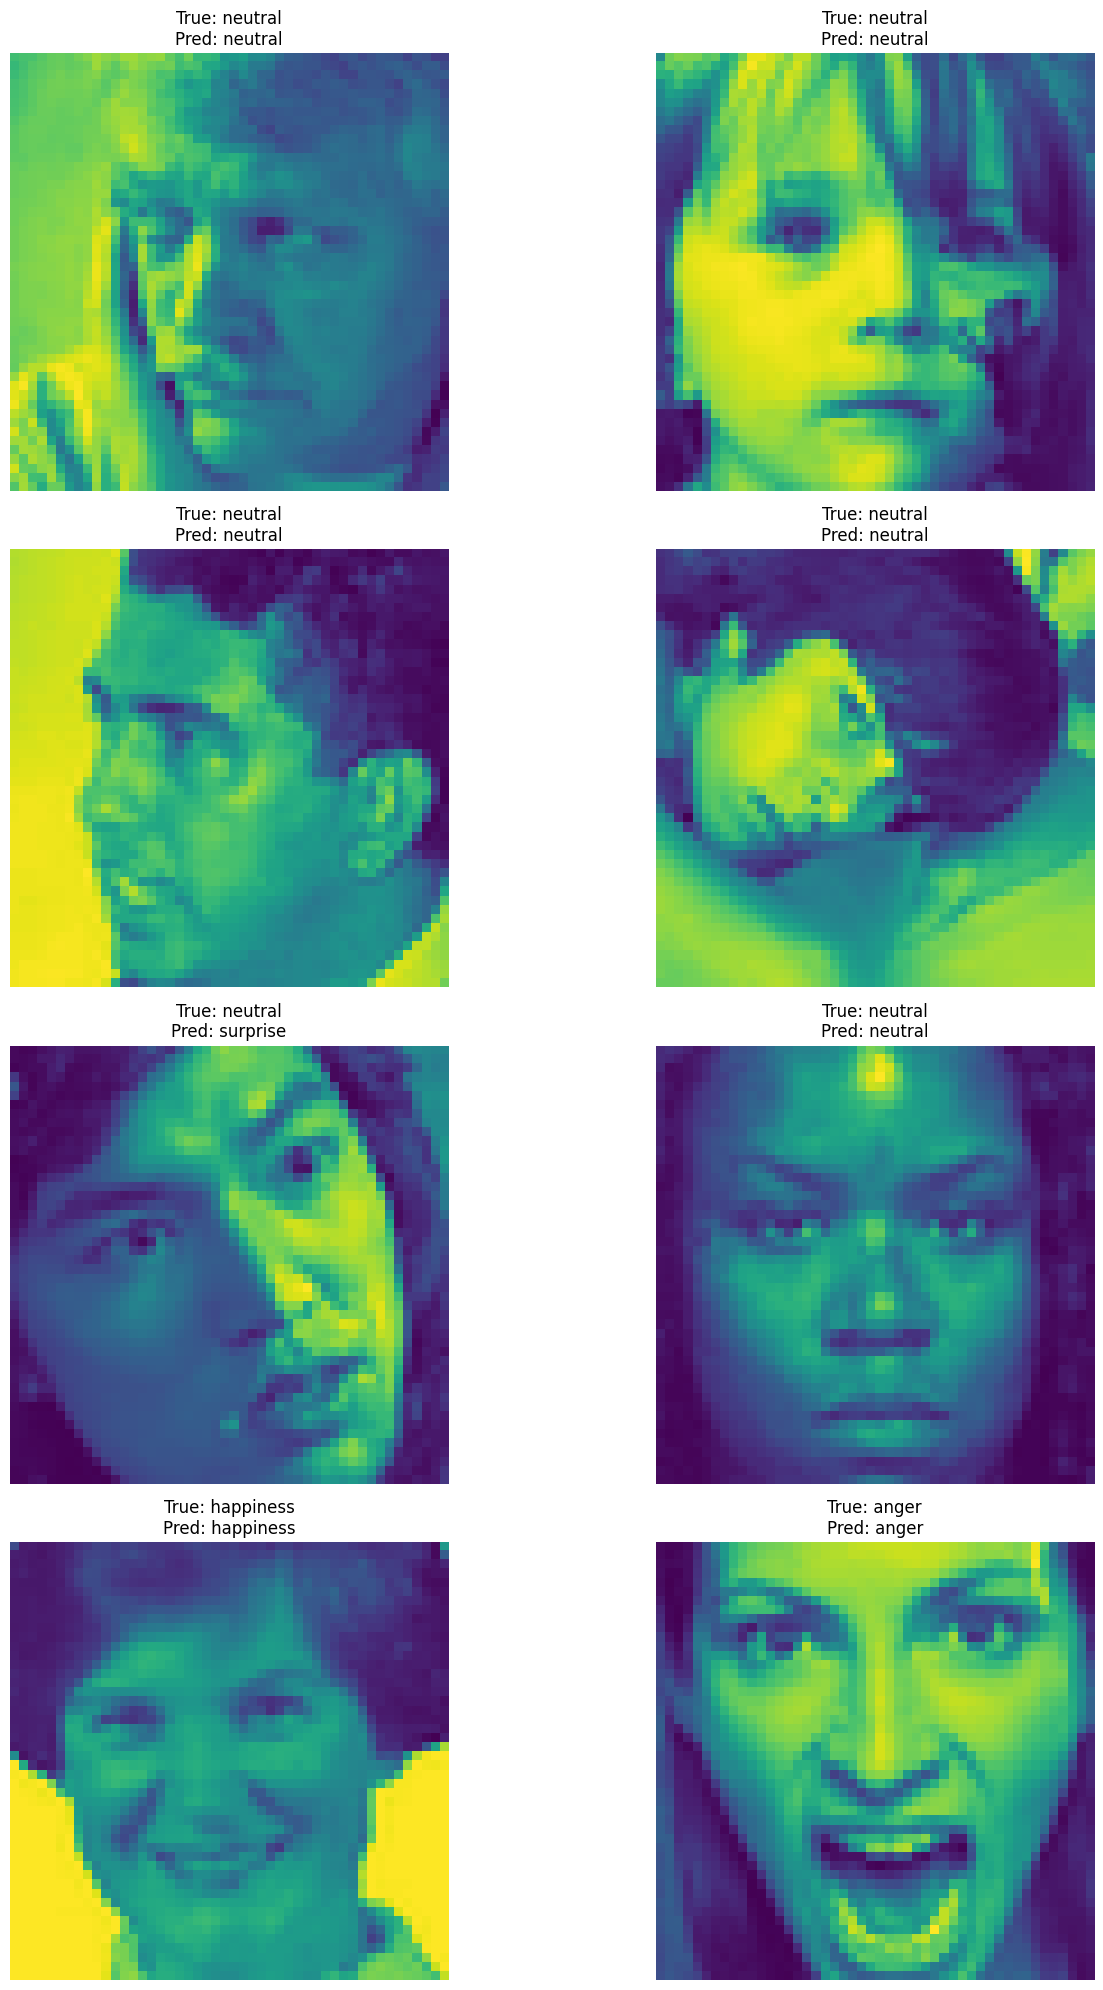

In [61]:
# Define class names
classes = train_dataset.classes  # Assuming you use ImageFolder or a similar dataset

# Visualize predictions
visualize_predictions_with_original_images(
    model=loaded_cnn_model,        # Your trained model
    data_loader=test_loader,  # DataLoader for the test dataset
    classes=classes,          # Class names
    num_images=8,             # Number of images to visualize
    device='cpu'              # Use 'cuda' if running on GPU
)
